# Preprocessing

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

In [2]:
# Mounta Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Create dataframe in VN
folder_path_vn = '/content/drive/MyDrive/NASDAQ/vn'
all_files_vn = glob.glob(os.path.join(folder_path_vn, "*.csv"))
df1 = []

for file in all_files_vn:
    raw_name = os.path.splitext(os.path.basename(file))[0]
    stock_name = raw_name.split('-')[0]
    vn = pd.read_csv(file, index_col=0)
    vn = vn.rename(columns={'TradingDate': 'Date'})
    vn['Ticker'] = stock_name
    df1.append(vn)

vn_df = pd.concat(df1, ignore_index=True)

# Create dataframe international
folder_path_int = '/content/drive/MyDrive/NASDAQ/int'
all_files_int = glob.glob(os.path.join(folder_path_int, "*.csv"))
df2 = []

for file in all_files_int:
    try:
        stock_name = os.path.splitext(os.path.basename(file))[0]
        inter = pd.read_csv(file, on_bad_lines='skip')
        inter['Ticker'] = stock_name
        df2.append(inter)
    except Exception as e:
        print(f"Error reading {file}: {e}")

int_df = pd.concat(df2, ignore_index=True)

print(vn_df.head(5))
print(int_df.head(5))

     Open    High     Low   Close    Volume        Date Ticker
0  7589.0  7589.0  5639.0  6060.0  134800.0  2011-03-18    HU3
1  6087.0  6350.0  6060.0  6350.0   93180.0  2011-03-21    HU3
2  6587.0  6666.0  6587.0  6666.0   60400.0  2011-03-22    HU3
3  6983.0  6983.0  6983.0  6983.0   55760.0  2011-03-23    HU3
4  7246.0  7246.0  6666.0  6772.0   99550.0  2011-03-24    HU3
         Date      Low     Open  Volume     High    Close  Adjusted Close  \
0  09-10-1996  9.74662  9.74662   370.0  9.74662  9.74662        7.537575   
1  10-10-1996  9.74662  9.74662     0.0  9.74662  9.74662        7.537575   
2  11-10-1996  9.74662  9.74662     0.0  9.74662  9.74662        7.537575   
3  14-10-1996  9.74662  9.74662     0.0  9.74662  9.74662        7.537575   
4  15-10-1996  9.74662  9.74662     0.0  9.74662  9.74662        7.537575   

  Ticker  
0   FFNM  
1   FFNM  
2   FFNM  
3   FFNM  
4   FFNM  


In [ ]:
# Get some info of datasets
print(vn_df.info())
print(int_df.info())

# Describe datasets
print(vn_df.describe)
print(int_df.describe)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3719441 entries, 0 to 3719440
Data columns (total 7 columns):
 #   Column  Dtype  
---  ------  -----  
 0   Open    float64
 1   High    float64
 2   Low     float64
 3   Close   float64
 4   Volume  float64
 5   Date    object 
 6   Ticker  object 
dtypes: float64(5), object(2)
memory usage: 198.6+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8752323 entries, 0 to 8752322
Data columns (total 8 columns):
 #   Column          Dtype  
---  ------          -----  
 0   Date            object 
 1   Low             float64
 2   Open            float64
 3   Volume          float64
 4   High            float64
 5   Close           float64
 6   Adjusted Close  float64
 7   Ticker          object 
dtypes: float64(6), object(2)
memory usage: 534.2+ MB
None
<bound method NDFrame.describe of            Open    High     Low   Close    Volume        Date Ticker
0        7589.0  7589.0  5639.0  6060.0  134800.0  2011-03-18    HU3
1      

# NASDAQ

In [ ]:
# Task 1.1
# Feature engineering
def add_new_features(df):
    df = df.sort_values(by=['Ticker', 'Date']).reset_index(drop=True)

    # Return (Daily + Log)
    df['Daily_Return'] = df.groupby('Ticker')['Close'].pct_change(fill_method=None)
    df['Log_Return'] = df.groupby('Ticker')['Close'].transform(lambda x: np.log(x / x.shift(1)))

    # Volatility and Daily Range
    df['Volatility_10'] = df.groupby('Ticker')['Daily_Return'].transform(lambda x: x.rolling(window=10).std())
    df['Daily_Range_Pct'] = (df['High'] - df['Low']) / df['Open']

    # Lag
    df['Close_Lag1'] = df.groupby('Ticker')['Close'].shift(1)
    df['Close_Lag2'] = df.groupby('Ticker')['Close'].shift(2)
    df['Volume_Lag1'] = df.groupby('Ticker')['Volume'].shift(1)

    # Drop NA
    df = df.dropna().reset_index(drop=True)

    return df

# Create new features
int_df = add_new_features(int_df)

# Example
print(int_df.head(3))

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


         Date    Low       Open      Volume       High      Close  \
0  01-02-2019  35.77  35.770000   6611900.0  36.590000  36.110001   
1  01-02-2021  16.33  17.250000  49436000.0  17.330000  16.840000   
2  01-02-2022  16.41  16.559999  30798800.0  16.969999  16.830000   

   Adjusted Close Ticker  Daily_Return  Log_Return  Volatility_10  \
0       35.535397    AAL     -0.329807   -0.400190       0.782141   
1       16.840000    AAL     -0.533647   -0.762813       0.775771   
2       16.830000    AAL     -0.000594   -0.000594       0.719099   

   Daily_Range_Pct  Close_Lag1  Close_Lag2  Volume_Lag1  
0         0.022924   53.880001   44.049999    3623100.0  
1         0.057971   36.110001   53.880001    6611900.0  
2         0.033816   16.840000   36.110001   49436000.0  


Final Global MdAPE: 29.18%



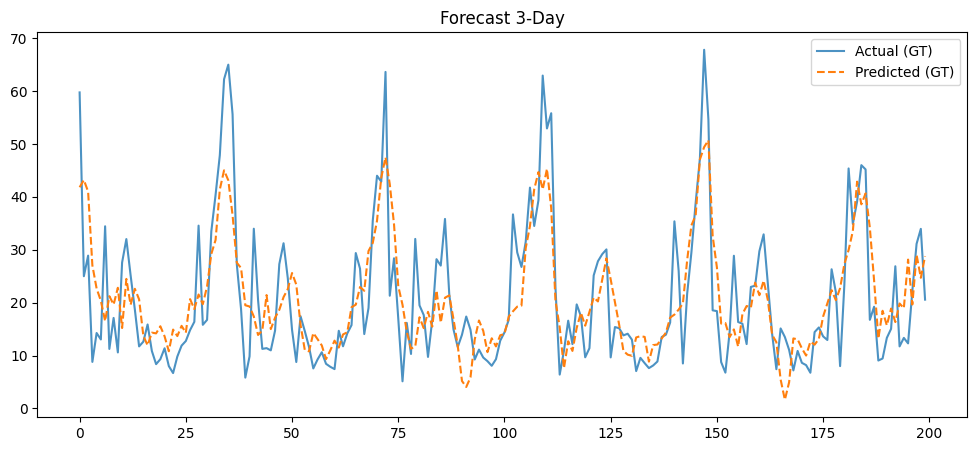

     Ticker  Close  Actual_USD  Pred_USD
7416   AAME   2.67        0.73  2.980276
7417   AAME   4.02        1.34  3.493736
7418   AAME   1.60        2.70  2.958761
7419   AAME   0.73        3.91  2.924916
7420   AAME   1.34        3.93  3.740506
7421   AAME   2.70        3.69  3.852854
7422   AAME   3.91        2.50  3.431484
7423   AAME   3.93        2.49  3.214302
7424   AAME   3.69        1.88  2.875583
7425   AAME   2.50        4.26  3.201194


In [ ]:
# Task 1.2
import torch, gc
import pandas as pd
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

# Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
K_DAYS, WINDOW_SIZE, BATCH_SIZE = 3, 60, 256

# Filter top 200 tickers by volume
top_tickers = int_df['Ticker'].value_counts().nlargest(200).index
df = int_df[int_df['Ticker'].isin(top_tickers)].copy()
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)
df['Target_Diff'] = df.groupby('Ticker')['Close'].shift(-K_DAYS) - df['Close']
df = df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

f_cols = [c for c in df.columns if c not in ['Ticker', 'Date', 'Target_Diff']]

# Initialize containers for scaled data and local scalers
scaled_f = np.zeros((len(df), len(f_cols)), dtype=np.float32)
scaled_t = np.zeros(len(df), dtype=np.float32)
train_idx, test_idx, target_scalers = [], [], {}

# Local Scaling for each ticker
for ticker, g in df.groupby('Ticker'):
    idx = g.index.values
    if len(idx) < WINDOW_SIZE + 10: continue

    split = int(len(idx) * 0.8)
    tr_rows, te_rows = idx[:split], idx[split:]

    f_scaler, t_scaler = StandardScaler(), StandardScaler()
    f_scaler.fit(df.loc[tr_rows, f_cols])
    t_scaler.fit(df.loc[tr_rows, ['Target_Diff']])

    scaled_f[idx] = f_scaler.transform(df.loc[idx, f_cols])
    scaled_t[idx] = t_scaler.transform(df.loc[idx, ['Target_Diff']]).flatten()

    target_scalers[ticker] = t_scaler
    train_idx.extend([i for i in tr_rows if i + WINDOW_SIZE - 1 < tr_rows[-1]])
    test_idx.extend([i for i in te_rows if i + WINDOW_SIZE - 1 < te_rows[-1]])

# Model
class TSDataset(Dataset):
    def __init__(self, f, t, idx):
        self.f, self.t, self.idx = torch.from_numpy(f), torch.from_numpy(t), idx
    def __len__(self): return len(self.idx)
    def __getitem__(self, i):
        s = self.idx[i]
        return self.f[s:s+WINDOW_SIZE], self.t[s+WINDOW_SIZE-1].unsqueeze(0)

train_loader = DataLoader(TSDataset(scaled_f, scaled_t, train_idx), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(TSDataset(scaled_f, scaled_t, test_idx), batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)

class CNN(nn.Module):
    def __init__(self, in_sz):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_sz, 64, 3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout1d(0.2),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, 3, padding=2, dilation =2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3), # Dropout
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.fc(self.net(x.permute(0, 2, 1)).squeeze(-1))

int_k_th = CNN(len(f_cols)).to(device)
opt = torch.optim.Adam(int_k_th.parameters(), lr=1e-3)
crit = nn.MSELoss()
scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None

# Training Loop
for epoch in range(20):
    int_k_th.train()
    for X, y in train_loader:
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
        opt.zero_grad()
        if scaler:
            with torch.amp.autocast('cuda'): loss = crit(int_k_th(X), y)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(int_k_th.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()
        else:
            loss = crit(int_k_th(X), y)
            loss.backward()
            nn.utils.clip_grad_norm_(int_k_th.parameters(), 1.0)
            opt.step()

# Inference
int_k_th.eval()
preds_scaled = []
with torch.no_grad():
    for X, y in test_loader:
        preds_scaled.extend(int_k_th(X.to(device, non_blocking=True)).cpu().numpy())

# Map predictions back to original scale and reconstruct prices
target_indices = [s + WINDOW_SIZE - 1 for s in test_idx]
test_df = df.loc[target_indices].copy()
test_df['Pred_Diff_Scaled'] = np.array(preds_scaled).flatten()
test_df['Pred_Diff_USD'] = 0.0

for ticker, group in test_df.groupby('Ticker'):
    t_scaler = target_scalers[ticker]
    test_df.loc[group.index, 'Pred_Diff_USD'] = t_scaler.inverse_transform(group[['Pred_Diff_Scaled']]).flatten()

# Final Reconstructed Prediction: Today's Close + Predicted Difference
test_df['Actual_USD'] = test_df['Close'] + test_df['Target_Diff']
test_df['Pred_USD'] = test_df['Close'] + test_df['Pred_Diff_USD']

# Accuracy Metric: Median Absolute Percentage Error (MdAPE)
test_df['MAPE'] = np.abs((test_df['Actual_USD'] - test_df['Pred_USD']) / test_df['Actual_USD']) * 100
mdape_score = test_df['MAPE'].median()

print(f"Final Global MdAPE: {mdape_score:.2f}%\n")

# Visualization
sample_ticker = top_tickers[0]
sample_df = test_df[test_df['Ticker'] == sample_ticker]
plt.figure(figsize=(12, 5))
plt.plot(sample_df['Actual_USD'].values[:200], label=f'Actual ({sample_ticker})', alpha=0.8)
plt.plot(sample_df['Pred_USD'].values[:200], label=f'Predicted ({sample_ticker})', linestyle='--')
plt.title(f"Forecast 3-Day")
plt.legend()
plt.show()

# Example Predictions
print(test_df[['Ticker', 'Close', 'Actual_USD', 'Pred_USD']].head(10))

In [ ]:
import joblib

# Save weight
torch.save(int_k_th.state_dict(), 'int_kth.pth')

# Save target_scalers
joblib.dump(target_scalers, 'target_scalers_kth_int.joblib')

# Save f_cols
joblib.dump(f_cols, 'f_cols_kth_int.joblib')

# Save convig
config = {
    'WINDOW_SIZE': WINDOW_SIZE,
    'K_DAYS': K_DAYS,
    'in_sz': len(f_cols),
    'out_sz': K_DAYS
}
joblib.dump(config, 'config_kth_inth.joblib')

['config_kth_inth.joblib']

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  super().__init__("GRU", *args, **kwargs)


Epoch 5 | Loss: 0.2366
Epoch 10 | Loss: 0.2198
Epoch 15 | Loss: 0.2124
Epoch 20 | Loss: 0.2080

Global MdAPE (Averaged over 5 days): 22.48%



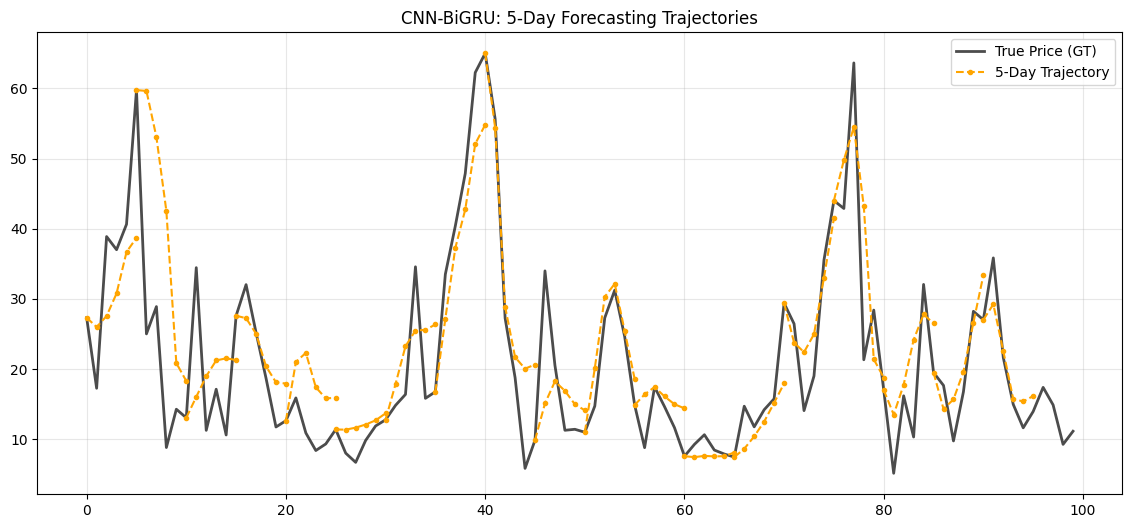

TICKER     | DATE         | DAY        | ACTUAL USD   | PRED USD     | ERROR %
--------------------------------------------------------------------------------
PATK       | 27-04-2010   | Day T+1     | 1.07         | 2.36         | 121.01%
           |              | Day T+2     | 5.78         | 7.49         | 29.58%
           |              | Day T+3     | 27.01        | 15.81        | 41.46%
           |              | Day T+4     | 32.67        | 31.11        | 4.77%
           |              | Day T+5     | 48.27        | 45.65        | 5.41%
--------------------------------------------------------------------------------
CBSH       | 30-09-2021   | Day T+1     | 66.16        | 67.14        | 1.48%
           |              | Day T+2     | 0.87         | 9.70         | 1017.92%
           |              | Day T+3     | 1.01         | 7.35         | 630.01%
           |              | Day T+4     | 1.73         | 9.17         | 428.38%
           |              | Day T+5     | 2.33

In [ ]:
# Task 1.3
import torch, gc
import pandas as pd
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

# Config
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
K_DAYS, WINDOW_SIZE, BATCH_SIZE = 5, 60, 256

# Data Prep
top_tickers = int_df['Ticker'].value_counts().nlargest(200).index
df = int_df[int_df['Ticker'].isin(top_tickers)].copy()
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

# Create multi-step target differences (Anchored targets)
target_cols = []
for k in range(1, K_DAYS + 1):
    col_name = f'Target_Diff_{k}'
    df[col_name] = df.groupby('Ticker')['Close'].shift(-k) - df['Close']
    target_cols.append(col_name)

df = df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
f_cols = [c for c in df.columns if c not in ['Ticker', 'Date'] + target_cols]

# Local Scaling (Fixed Leakage: Fit only on Train, Transform on Test)
scaled_f = np.zeros((len(df), len(f_cols)), dtype=np.float32)
scaled_t = np.zeros((len(df), K_DAYS), dtype=np.float32)
train_idx, test_idx, target_scalers = [], [], {}

for ticker, g in df.groupby('Ticker'):
    idx = g.index.values
    if len(idx) < WINDOW_SIZE + K_DAYS + 10: continue

    split = int(len(idx) * 0.8)
    tr_rows, te_rows = idx[:split], idx[split:]

    f_scaler, t_scaler = StandardScaler(), StandardScaler()

    # Fit only on training rows to avoid looking into the future
    f_scaler.fit(df.loc[tr_rows, f_cols])
    t_scaler.fit(df.loc[tr_rows, target_cols])

    # Transform both sets using train-based parameters
    scaled_f[idx] = f_scaler.transform(df.loc[idx, f_cols])
    scaled_t[idx] = t_scaler.transform(df.loc[idx, target_cols])

    target_scalers[ticker] = t_scaler
    train_idx.extend([i for i in tr_rows if i + WINDOW_SIZE - 1 < tr_rows[-1]])
    test_idx.extend([i for i in te_rows if i + WINDOW_SIZE - 1 < te_rows[-1]])

# Dataset & DataLoader
class TSDataset(Dataset):
    def __init__(self, f, t, idx):
        self.f, self.t, self.idx = torch.from_numpy(f), torch.from_numpy(t), idx
    def __len__(self): return len(self.idx)
    def __getitem__(self, i):
        s = self.idx[i]
        return self.f[s:s+WINDOW_SIZE], self.t[s+WINDOW_SIZE-1]

train_loader = DataLoader(TSDataset(scaled_f, scaled_t, train_idx), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(TSDataset(scaled_f, scaled_t, test_idx), batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)

# CNN-BiGRU Model (Added Dropout to prevent Overfitting)
class CNN_BiGRU(nn.Module):
    def __init__(self, in_sz, out_sz):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_sz, 64, 3, padding=1), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Dropout1d(0.2), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, 3, padding=2, dilation = 2), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Dropout1d(0.2)
        )
        self.rnn = nn.GRU(128, 64, batch_first=True, bidirectional=True, dropout=0.3)
        self.fc = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, out_sz)
        )

    def forward(self, x):
        c_out = self.cnn(x.permute(0, 2, 1))
        _, h_n = self.rnn(c_out.permute(0, 2, 1))
        # Concat hidden states from both directions
        out = torch.cat((h_n[-2, :, :], h_n[-1, :, :]), dim=1)
        return self.fc(out)

int_kdays = CNN_BiGRU(len(f_cols), K_DAYS).to(device)
opt = torch.optim.Adam(int_kdays.parameters(), lr=1e-3, weight_decay=1e-5) # Added Weight Decay
crit = nn.MSELoss()
scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None

# Training
for epoch in range(20):
    int_kdays.train()
    total_loss = 0
    for X, y in train_loader:
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
        opt.zero_grad()
        if scaler:
            with torch.amp.autocast('cuda'): loss = crit(int_kdays(X), y)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(int_kdays.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()
        else:
            loss = crit(int_kdays(X), y)
            loss.backward()
            nn.utils.clip_grad_norm_(int_kdays.parameters(), 1.0)
            opt.step()
        total_loss += loss.item()
    if (epoch + 1) % 5 == 0: print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f}")

# Evaluation
int_kdays.eval()
preds_scaled = []
with torch.no_grad():
    for X, y in test_loader:
        preds_scaled.extend(int_kdays(X.to(device, non_blocking=True)).cpu().numpy())

preds_scaled = np.array(preds_scaled)
target_indices = [s + WINDOW_SIZE - 1 for s in test_idx]
test_df = df.loc[target_indices].copy().reset_index(drop=True)

# Reconstruct USD prices from differences
pred_usd_diff = np.zeros_like(preds_scaled)
for ticker, group in test_df.groupby('Ticker'):
    pred_usd_diff[group.index] = target_scalers[ticker].inverse_transform(preds_scaled[group.index])

base_price = test_df['Close'].values.reshape(-1, 1)
actual_usd = test_df[target_cols].values + base_price
pred_usd = pred_usd_diff + base_price

# Calculate MdAPE
mape_matrix = np.abs((actual_usd - pred_usd) / actual_usd) * 100
print(f"\nGlobal MdAPE (Averaged over {K_DAYS} days): {np.median(mape_matrix):.2f}%\n")

# Plot Trajectory
sample_ticker = top_tickers[0]
sample_idx = test_df.index[test_df['Ticker'] == sample_ticker].tolist()

plt.figure(figsize=(14, 6))
main_actuals = test_df.loc[sample_idx, 'Close'].values[:100]
plt.plot(main_actuals, label=f'True Price ({sample_ticker})', color='black', linewidth=2, alpha=0.7)

for i in range(0, 95, 5):
    plt.plot(range(i, i + K_DAYS + 1), [main_actuals[i]] + list(pred_usd[sample_idx[i]]),
             color='orange', linestyle='--', marker='o', markersize=3,
             label=f'{K_DAYS}-Day Trajectory' if i == 0 else "")

plt.title(f"CNN-BiGRU: {K_DAYS}-Day Forecasting Trajectories")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# Prediction Example

def get_prediction_examples(n_examples=3):
    # Select n random indices from the test set
    random_indices = np.random.choice(len(test_df), n_examples, replace=False)

    print(f"{'='*80}")
    print(f"{'TICKER':<10} | {'DATE':<12} | {'DAY':<10} | {'ACTUAL USD':<12} | {'PRED USD':<12} | {'ERROR %'}")
    print(f"{'-'*80}")

    for idx in random_indices:
        ticker = test_df.iloc[idx]['Ticker']
        date = test_df.iloc[idx]['Date']
        start_price = test_df.iloc[idx]['Close']

        # Get the 5-day sequences
        actual_path = actual_usd[idx]
        pred_path = pred_usd[idx]

        for k in range(K_DAYS):
            actual = actual_path[k]
            pred = pred_path[k]
            error = abs(actual - pred) / actual * 100

            # Print ticker and date only on the first row of the sequence
            t_str = ticker if k == 0 else ""
            d_str = str(date)[:10] if k == 0 else ""

            print(f"{t_str:<10} | {d_str:<12} | Day T+{k+1:<5} | {actual:<12.2f} | {pred:<12.2f} | {error:.2f}%")
        print(f"{'-'*80}")

# Execute Example
get_prediction_examples(n_examples=3)

# Summary Statistics by Forecast Horizon
print("\nMdAPE per Forecast Day:")
for k in range(K_DAYS):
    day_mape = np.median(mape_matrix[:, k])
    print(f"Day T+{k+1}: {day_mape:.2f}%")

In [ ]:
import joblib

# Save weight
torch.save(int_kdays.state_dict(), 'int_kdays.pth')

# Save target_scalers
joblib.dump(target_scalers, 'target_scalers_kdays_int.joblib')

# Save f_cols
joblib.dump(f_cols, 'f_cols_kdays_int.joblib')

# Save convig
config = {
    'WINDOW_SIZE': WINDOW_SIZE,
    'K_DAYS': K_DAYS,
    'in_sz': len(f_cols),
    'out_sz': K_DAYS
}
joblib.dump(config, 'config_kdays_int.joblib')

['config_kdays_int.joblib']

# Vietnam

In [4]:
# Task 2.1
def add_new_features(df):
    df = df.sort_values(by=['Ticker', 'Date']).reset_index(drop=True)
    ticker_group = df.groupby('Ticker')

    # 1. Return (Daily + Log)
    df['Daily_Return'] = ticker_group['Close'].pct_change(fill_method=None)
    df['Log_Return'] = ticker_group['Close'].transform(lambda x: np.log(x / x.shift(1)))

    # 2. Volatility and Daily Range
    df['Volatility_10'] = ticker_group['Daily_Return'].transform(lambda x: x.rolling(window=10).std())
    df['Daily_Range_Pct'] = (df['High'] - df['Low']) / df['Open']

    # 3. Lag
    df['Close_Lag1'] = ticker_group['Close'].shift(1)
    df['Close_Lag2'] = ticker_group['Close'].shift(2)
    df['Volume_Lag1'] = ticker_group['Volume'].shift(1)

    # 4. Technical Indicators
    # MACD
    ema12 = ticker_group['Close'].transform(lambda x: x.ewm(span=12).mean())
    ema26 = ticker_group['Close'].transform(lambda x: x.ewm(span=26).mean())
    df['MACD'] = ema12 - ema26

    # RSI (14 days)
    delta = ticker_group['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = ticker_group.apply(lambda x: gain.loc[x.index].rolling(14).mean(), include_groups=False).reset_index(level=0, drop=True)
    avg_loss = ticker_group.apply(lambda x: loss.loc[x.index].rolling(14).mean(), include_groups=False).reset_index(level=0, drop=True)
    df['RSI'] = 100 - (100 / (1 + avg_gain / avg_loss.replace(0, np.nan)))

    # Volume Change & On-Balance Volume (OBV)
    df['Vol_Change'] = ticker_group['Volume'].pct_change(fill_method=None)
    df['OBV'] = ticker_group.apply(lambda x: (np.sign(x['Close'].diff()) * x['Volume']).fillna(0).cumsum(), include_groups=False).reset_index(level=0, drop=True)

    return df

vn_df = add_new_features(vn_df.copy())
print(vn_df.head(3))

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


      Open     High      Low    Close  Volume        Date Ticker  \
0  15326.0  15326.0  15326.0  15300.0     0.0  2018-10-23    A32   
1  15326.0  15326.0  15326.0  15300.0     0.0  2018-10-24    A32   
2  15326.0  15326.0  15326.0  15300.0     0.0  2018-10-25    A32   

   Daily_Return  Log_Return  Volatility_10  Daily_Range_Pct  Close_Lag1  \
0           NaN         NaN            NaN              0.0         NaN   
1           0.0         0.0            NaN              0.0     15300.0   
2           0.0         0.0            NaN              0.0     15300.0   

   Close_Lag2  Volume_Lag1  MACD  RSI  Vol_Change  OBV  
0         NaN          NaN   0.0  NaN         NaN  0.0  
1         NaN          0.0   0.0  NaN         NaN  0.0  
2     15300.0          0.0   0.0  NaN         NaN  0.0  


Final Global MdAPE: 4.21%


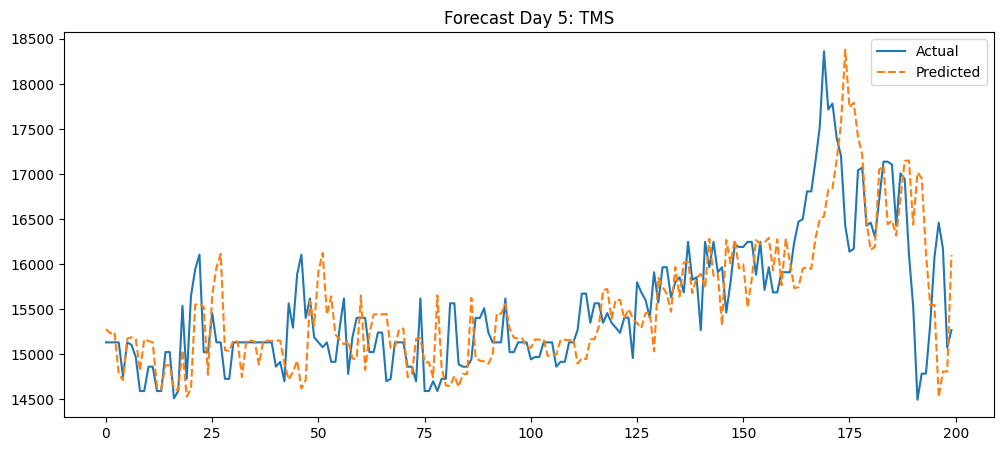

Ticker     | Date         | Close (T)    | Actual (T+K) | Pred (T+K)   | MAPE (%)  
----------------------------------------------------------------------------------------------------
PET        | 2020-09-17   | 8,247        | 8,422        | 8,235        | 2.22      %
MHC        | 2021-06-11   | 13,619       | 13,479       | 12,487       | 7.36      %
SIC        | 2021-03-19   | 14,200       | 14,500       | 14,209       | 2.01      %
VIC        | 2021-11-25   | 94,000       | 107,200      | 94,093       | 12.23     %
FPT        | 2020-10-14   | 35,456       | 36,707       | 35,334       | 3.74      %


In [5]:
# Task 2.2
import torch, gc
import pandas as pd
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

# Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
K_DAYS, WINDOW_SIZE, BATCH_SIZE = 5, 60, 256

# Filter top 200 tickers
top_tickers = vn_df['Ticker'].value_counts().nlargest(200).index
df = vn_df[vn_df['Ticker'].isin(top_tickers)].copy()
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

# Create target
df['Target_Diff'] = df.groupby('Ticker')['Close'].shift(-K_DAYS) - df['Close']

# Drop NA
df = df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
f_cols = [c for c in df.columns if c not in ['Ticker', 'Date', 'Target_Diff']]

# Initialize containers
scaled_f = np.zeros((len(df), len(f_cols)), dtype=np.float32)
scaled_t = np.zeros(len(df), dtype=np.float32)
train_idx, test_idx, target_scalers = [], [], {}

# Local Scaling
for ticker, g in df.groupby('Ticker'):
    idx = g.index.values
    if len(idx) < WINDOW_SIZE + 10: continue

    split = int(len(idx) * 0.8)
    tr_rows, te_rows = idx[:split], idx[split:]

    f_scaler, t_scaler = StandardScaler(), StandardScaler()
    f_scaler.fit(df.loc[tr_rows, f_cols])
    t_scaler.fit(df.loc[tr_rows, ['Target_Diff']])

    scaled_f[idx] = f_scaler.transform(df.loc[idx, f_cols])
    scaled_t[idx] = t_scaler.transform(df.loc[idx, ['Target_Diff']]).flatten()

    target_scalers[ticker] = t_scaler
    train_idx.extend([i for i in tr_rows if i + WINDOW_SIZE - 1 <= tr_rows[-1]])
    test_idx.extend([i for i in te_rows if i + WINDOW_SIZE - 1 <= te_rows[-1]])

class TSDataset(Dataset):
    def __init__(self, f, t, idx):
        self.f, self.t, self.idx = torch.from_numpy(f), torch.from_numpy(t), idx
    def __len__(self): return len(self.idx)
    def __getitem__(self, i):
        s = self.idx[i]
        return self.f[s:s+WINDOW_SIZE], self.t[s+WINDOW_SIZE-1].unsqueeze(0)

train_loader = DataLoader(TSDataset(scaled_f, scaled_t, train_idx), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TSDataset(scaled_f, scaled_t, test_idx), batch_size=BATCH_SIZE)

class CNN(nn.Module):
    def __init__(self, in_sz):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_sz, 64, 3, padding=1), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, 128, 3, padding=1), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2), nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3), # Dropout
            nn.Linear(64, 1)
        )
    def forward(self, x): return self.fc(self.net(x.permute(0, 2, 1)).squeeze(-1))

model_th = CNN(len(f_cols)).to(device)
opt = torch.optim.Adam(model_th.parameters(), lr=1e-3)
crit = nn.MSELoss()

# Training
for epoch in range(20):
    model_th.train()
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        opt.zero_grad()
        loss = crit(model_th(X), y)
        loss.backward()
        opt.step()

# Inference
model_th.eval()
preds_scaled = []
with torch.no_grad():
    for X, y in test_loader:
        preds_scaled.extend(model_th(X.to(device)).cpu().numpy())

target_indices = [s + WINDOW_SIZE - 1 for s in test_idx]
test_df = df.loc[target_indices].copy()
test_df['Pred_Diff_Scaled'] = np.array(preds_scaled).flatten()

for ticker, group in test_df.groupby('Ticker'):
    test_df.loc[group.index, 'Pred_Diff'] = target_scalers[ticker].inverse_transform(group[['Pred_Diff_Scaled']]).flatten()

# Reconstruct
test_df['Actual'] = test_df['Close'] + test_df['Target_Diff']
test_df['Pred'] = test_df['Close'] + test_df['Pred_Diff']

# MdAPE
test_df['MAPE'] = np.abs((test_df['Actual'] - test_df['Pred']) / test_df['Actual']) * 100
print(f"Final Global MdAPE: {test_df['MAPE'].median():.2f}%")

# Plot
sample_ticker = top_tickers[0]
sample_df = test_df[test_df['Ticker'] == sample_ticker].iloc[:200]
plt.figure(figsize=(12, 5))
plt.plot(sample_df['Actual'].values, label='Actual')
plt.plot(sample_df['Pred'].values, label='Predicted', linestyle='--')
plt.title(f"Forecast Day {K_DAYS}: {sample_ticker}")
plt.legend(); plt.show()

# Example
def get_prediction_examples(df_results, n_samples=5):
    samples = df_results.sample(n_samples).copy()

    samples['Actual_Move'] = samples['Actual'] - samples['Close']
    samples['Pred_Move'] = samples['Pred'] - samples['Close']

    print("="*100)
    header = f"{'Ticker':<10} | {'Date':<12} | {'Close (T)':<12} | {'Actual (T+K)':<12} | {'Pred (T+K)':<12} | {'MAPE (%)':<10}"
    print(header)
    print("-" * 100)

    for _, row in samples.iterrows():
        print(f"{row['Ticker']:<10} | "
              f"{str(row['Date'])[:10]:<12} | "
              f"{row['Close']:<12,.0f} | "
              f"{row['Actual']:<12,.0f} | "
              f"{row['Pred']:<12,.0f} | "
              f"{row['MAPE']:<10.2f}%")

    print("="*100)

get_prediction_examples(test_df, n_samples=5)

In [6]:
import joblib

# Save weight
torch.save(model_th.state_dict(), 'vn_kth.pth')

# Save target_scalers
joblib.dump(target_scalers, 'target_scalers_kth_vn.joblib')

# Save f_cols
joblib.dump(f_cols, 'f_cols_kth_vn.joblib')

# Save convig
config = {
    'WINDOW_SIZE': WINDOW_SIZE,
    'K_DAYS': K_DAYS,
    'in_sz': len(f_cols),
    'out_sz': K_DAYS
}
joblib.dump(config, 'config_kth_vn.joblib')

['config_kth_vn.joblib']

Global MdAPE: 3.00%



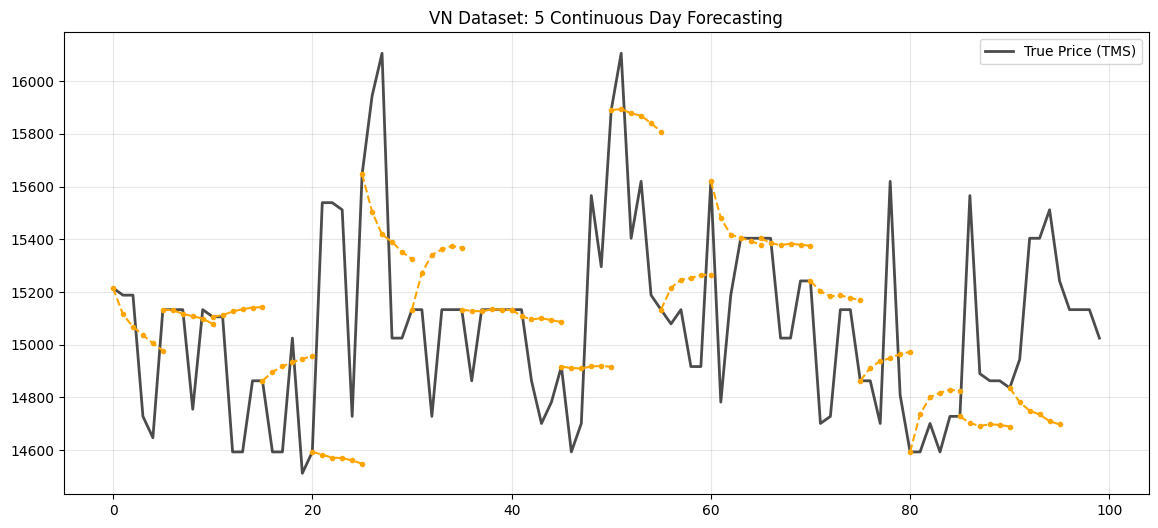


5-DAY FUTURE FORECAST FOR: TMS | Last Known: 53500.00 
---------------------------------------------
Day T+1: 53306.44 | Diff: -193.56 DOWN
Day T+2: 53206.01 | Diff: -293.99 DOWN
Day T+3: 53252.35 | Diff: -247.65 DOWN
Day T+4: 53313.31 | Diff: -186.69 DOWN
Day T+5: 53427.71 | Diff: -72.29 DOWN

5-DAY FUTURE FORECAST FOR: SAM | Last Known: 6100.00 
---------------------------------------------
Day T+1: 6103.69 | Diff:  +3.69 UP
Day T+2: 6116.31 | Diff: +16.31 UP
Day T+3: 6127.24 | Diff: +27.24 UP
Day T+4: 6138.09 | Diff: +38.09 UP
Day T+5: 6143.80 | Diff: +43.80 UP

5-DAY FUTURE FORECAST FOR: REE | Last Known: 71836.00 
---------------------------------------------
Day T+1: 71294.63 | Diff: -541.37 DOWN
Day T+2: 70759.91 | Diff: -1076.09 DOWN
Day T+3: 70439.62 | Diff: -1396.38 DOWN
Day T+4: 70236.61 | Diff: -1599.39 DOWN
Day T+5: 70166.36 | Diff: -1669.64 DOWN


In [21]:
# Task 2.3

import torch, gc
import pandas as pd
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

# Config
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
K_DAYS, WINDOW_SIZE, BATCH_SIZE = 5, 60, 256

# Data Prep
top_tickers = vn_df['Ticker'].value_counts().nlargest(200).index
df = vn_df[vn_df['Ticker'].isin(top_tickers)].copy()
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

# Create multi-step target differences
target_cols = []
for k in range(1, K_DAYS + 1):
    col_name = f'Target_Diff_{k}'
    df[col_name] = df.groupby('Ticker')['Close'].shift(-k) - df['Close']
    target_cols.append(col_name)

# Drop NA
df = df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
f_cols = [c for c in df.columns if c not in ['Ticker', 'Date'] + target_cols]

# Local Scaling (Leakage Fixed)
scaled_f = np.zeros((len(df), len(f_cols)), dtype=np.float32)
scaled_t = np.zeros((len(df), K_DAYS), dtype=np.float32)
train_idx, test_idx, target_scalers = [], [], {}

for ticker, g in df.groupby('Ticker'):
    idx = g.index.values
    if len(idx) < WINDOW_SIZE + K_DAYS + 10: continue

    split = int(len(idx) * 0.8)
    tr_rows, te_rows = idx[:split], idx[split:]

    f_scaler, t_scaler = StandardScaler(), StandardScaler()

    # Fit ONLY on training rows to prevent leakage
    f_scaler.fit(df.loc[tr_rows, f_cols])
    t_scaler.fit(df.loc[tr_rows, target_cols])

    # Transform all rows (train + test) based on training statistics
    scaled_f[idx] = f_scaler.transform(df.loc[idx, f_cols]).astype(np.float32)
    scaled_t[idx] = t_scaler.transform(df.loc[idx, target_cols]).astype(np.float32)

    target_scalers[ticker] = t_scaler
    train_idx.extend([i for i in tr_rows if i + WINDOW_SIZE - 1 <= tr_rows[-1]])
    test_idx.extend([i for i in te_rows if i + WINDOW_SIZE - 1 <= te_rows[-1]])

# Dataset & DataLoader
class TSDataset(Dataset):
    def __init__(self, f, t, idx):
        self.f, self.t, self.idx = torch.from_numpy(f), torch.from_numpy(t), idx
    def __len__(self): return len(self.idx)
    def __getitem__(self, i):
        s = self.idx[i]
        return self.f[s:s+WINDOW_SIZE], self.t[s+WINDOW_SIZE-1]

train_loader = DataLoader(TSDataset(scaled_f, scaled_t, train_idx), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(TSDataset(scaled_f, scaled_t, test_idx), batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)

# Model Architecture
class CNN_BiGRU(nn.Module):
    def __init__(self, in_sz, out_sz):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_sz, 64, 3, padding=1), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, 128, 3, padding=1), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2)
        )
        self.rnn = nn.GRU(128, 64, batch_first=True, bidirectional=True)
        self.fc = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, out_sz)
        )

    def forward(self, x):
        c_out = self.cnn(x.permute(0, 2, 1))
        _, h_n = self.rnn(c_out.permute(0, 2, 1))
        return self.fc(torch.cat((h_n[-2, :, :], h_n[-1, :, :]), dim=1))

model = CNN_BiGRU(len(f_cols), K_DAYS).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
crit = nn.MSELoss()
scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None

# Training Loop
for epoch in range(20):
    model.train()
    for X, y in train_loader:
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
        opt.zero_grad()
        if scaler:
            with torch.amp.autocast('cuda'): loss = crit(model(X), y)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()
        else:
            loss = crit(model(X), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

# Evaluation
model.eval()
preds_scaled = []
with torch.no_grad():
    for X, y in test_loader:
        preds_scaled.extend(model(X.to(device, non_blocking=True)).cpu().numpy())

preds_scaled = np.array(preds_scaled)
target_indices = [s + WINDOW_SIZE - 1 for s in test_idx]
test_df = df.loc[target_indices].copy().reset_index(drop=True)

# Inverse Scaling & Reconstruction
pred_usd_diff = np.zeros_like(preds_scaled)
for ticker, group in test_df.groupby('Ticker'):
    pred_usd_diff[group.index] = target_scalers[ticker].inverse_transform(preds_scaled[group.index])

base_price = test_df['Close'].values.reshape(-1, 1)
actual_usd = test_df[target_cols].values + base_price
pred_usd = pred_usd_diff + base_price

# Metrics
mape_matrix = np.abs((actual_usd - pred_usd) / actual_usd) * 100
print(f"Global MdAPE: {np.median(mape_matrix):.2f}%\n")

# Plotting
sample_ticker = top_tickers[0]
sample_idx = test_df.index[test_df['Ticker'] == sample_ticker].tolist()
plt.figure(figsize=(14, 6))
main_actuals = test_df.loc[sample_idx, 'Close'].values[:100]
plt.plot(main_actuals, label=f'True Price ({sample_ticker})', color='black', linewidth=2, alpha=0.7)

for i in range(0, 95, 5):
    plt.plot(range(i, i + K_DAYS + 1), [main_actuals[i]] + list(pred_usd[sample_idx[i]]),
             color='orange', linestyle='--', marker='o', markersize=3)

plt.title(f"VN Dataset: {K_DAYS} Continuous Day Forecasting")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# Out-of-Sample Inference
def predict_future_k_days(ticker_name):
    model.eval()
    ticker_idx = df[df['Ticker'] == ticker_name].index.values
    if len(ticker_idx) < WINDOW_SIZE: return

    X_input = torch.tensor(scaled_f[ticker_idx[-WINDOW_SIZE:]], dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        pred_diff_usd = target_scalers[ticker_name].inverse_transform(model(X_input).cpu().numpy())[0]

    last_close = df.loc[ticker_idx[-1], 'Close']
    print(f"\n{K_DAYS}-DAY FUTURE FORECAST FOR: {ticker_name} | Last Known: {last_close:.2f} \n" + "-" * 45)
    for i in range(K_DAYS):
        print(f"Day T+{i+1}: {last_close + pred_diff_usd[i]:.2f} | Diff: {pred_diff_usd[i]:+6.2f} {'UP' if pred_diff_usd[i] > 0 else 'DOWN'}")

for t in top_tickers[:3]: predict_future_k_days(t)

In [8]:
import joblib

# Save weight
torch.save(model.state_dict(), 'vn_kdays.pth')

# Save target_scalers
joblib.dump(target_scalers, 'target_scalers_kdays_vn.joblib')

# Save f_cols
joblib.dump(f_cols, 'f_cols_kdays_vn.joblib')

# Save convig
config = {
    'WINDOW_SIZE': WINDOW_SIZE,
    'K_DAYS': K_DAYS,
    'in_sz': len(f_cols),
    'out_sz': K_DAYS
}
joblib.dump(config, 'config_kdays_vn.joblib')

['config_kdays_vn.joblib']

After Undersampling - Buy: 224345, No Buy: 224345
              precision    recall  f1-score   support

      No Buy       0.54      0.70      0.61     50397
         Buy       0.52      0.36      0.42     46208

    accuracy                           0.53     96605
   macro avg       0.53      0.53      0.52     96605
weighted avg       0.53      0.53      0.52     96605

--- Sample Probability Scores ---
       Probability_Score  Actual
36289           0.959086     1.0
88228           0.958237     1.0
80724           0.956031     1.0
80725           0.954937     1.0
36291           0.954014     1.0
36290           0.952275     1.0
88227           0.951669     1.0
80723           0.951338     1.0
88229           0.945503     1.0
80726           0.944619     1.0


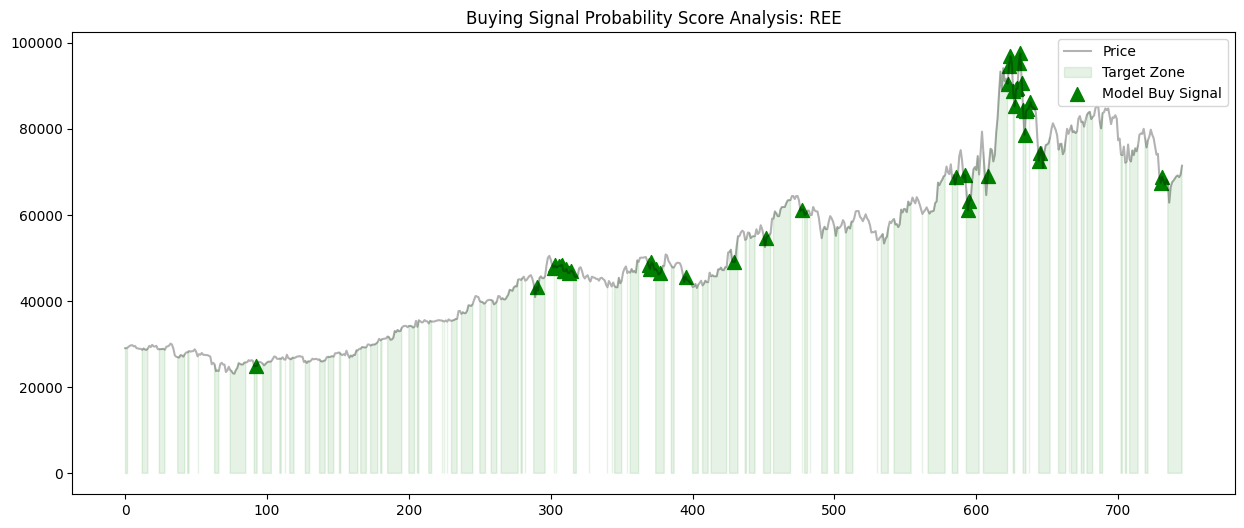

In [9]:
# Task 3.1: Buying signal

import torch, copy, pandas as pd, numpy as np, torch.nn as nn, matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report

# 1. Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
K_DAYS, WINDOW_SIZE, BATCH_SIZE, PROFIT_THRESHOLD = 5, 60, 64, 0.015

df_buy = vn_df[vn_df['Volume'] > 0].copy()
top_tickers = df_buy['Ticker'].value_counts().nlargest(200).index
df_buy = df_buy[df_buy['Ticker'].isin(top_tickers)]
df_buy = df_buy.sort_values(['Ticker', 'Date']).reset_index(drop=True)

# 2. Target Generation
df_buy['Buy_Signal'] = ((df_buy.groupby('Ticker')['High'].shift(-K_DAYS) / df_buy['Close']) - 1 > PROFIT_THRESHOLD).astype(int)
df_buy = df_buy.replace([np.inf, -np.inf], np.nan)
df_buy = df_buy.dropna().reset_index(drop=True)

# 3. Scaling & Split
f_cols = [c for c in df_buy.columns if c not in ['Ticker', 'Date', 'Buy_Signal', 'Signal', 'Sell_Signal']]
scaled_f = np.zeros((len(df_buy), len(f_cols)), dtype=np.float32)
targets = df_buy['Buy_Signal'].values
train_idx, val_idx, test_idx = [], [], []

for ticker, g in df_buy.groupby('Ticker'):
    idx = g.index.values
    if len(idx) < WINDOW_SIZE + 10: continue
    tr_end, val_end = int(len(idx)*0.7), int(len(idx)*0.85)
    scaler_buy = RobustScaler().fit(df_buy.loc[idx[:tr_end], f_cols])
    scaled_f[idx] = scaler_buy.transform(df_buy.loc[idx, f_cols])
    train_idx.extend([i for i in idx[:tr_end] if i + WINDOW_SIZE - 1 < idx[tr_end-1]])
    val_idx.extend([i for i in idx[tr_end:val_end] if i + WINDOW_SIZE - 1 < idx[val_end-1]])
    test_idx.extend([i for i in idx[val_end:] if i + WINDOW_SIZE - 1 < idx[-1]])

# Undersampling
train_buy_idx = [i for i in train_idx if targets[i + WINDOW_SIZE - 1] == 1]
train_no_buy_idx = [i for i in train_idx if targets[i + WINDOW_SIZE - 1] == 0]

n_no_buy_target = int(len(train_buy_idx) * 1.0)
n_no_buy = min(len(train_no_buy_idx), n_no_buy_target)
keep_no_buy_idx = np.random.choice(train_no_buy_idx, n_no_buy, replace=False).tolist()

undersampled_train_idx = train_buy_idx + keep_no_buy_idx
np.random.shuffle(undersampled_train_idx)
print(f"After Undersampling - Buy: {len(train_buy_idx)}, No Buy: {len(keep_no_buy_idx)}")

# 4. Model Architecture
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        weights = torch.softmax(self.attn(x), dim=1)
        return torch.sum(weights * x, dim=1)

class SOTA_Model(nn.Module):
    def __init__(self, in_sz):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_sz, 64, 3, padding=1), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, 128, 3, padding=1), nn.BatchNorm1d(128), nn.ReLU(),
            nn.MaxPool1d(2)
        )
        self.rnn = nn.GRU(128, 64, batch_first=True, bidirectional=True)
        self.attention = Attention(128)
        self.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(128, 1))
    def forward(self, x):
        x = self.cnn(x.permute(0, 2, 1))
        x, _ = self.rnn(x.permute(0, 2, 1))
        x = self.attention(x)
        return self.fc(x)

class BuyDataset(Dataset):
    def __init__(self, f, t, idx): self.f, self.t, self.idx = torch.from_numpy(f), torch.from_numpy(t), idx
    def __len__(self): return len(self.idx)
    def __getitem__(self, i):
        s = self.idx[i]
        return self.f[s:s+WINDOW_SIZE], self.t[s+WINDOW_SIZE-1].float().unsqueeze(0)

# 5. Training
model_buy = SOTA_Model(len(f_cols)).to(device)
crit = nn.BCEWithLogitsLoss()
opt = torch.optim.AdamW(model_buy.parameters(), lr=1e-4)
loader = DataLoader(BuyDataset(scaled_f, targets, undersampled_train_idx), batch_size=BATCH_SIZE, shuffle=True)

for epoch in range(15):
    model_buy.train()
    for X, y in loader:
        opt.zero_grad(); crit(model_buy(X.to(device)), y.to(device)).backward(); opt.step()

# 6. Evaluation
model_buy.eval()
all_probs, all_targets, scoring_results = [], [], []

test_loader = DataLoader(BuyDataset(scaled_f, targets, test_idx), batch_size=BATCH_SIZE)
with torch.no_grad():
    for X, y in test_loader:
        # Sigmoid converts raw output to probability score
        prob = torch.sigmoid(model_buy(X.to(device))).cpu().numpy()
        all_probs.extend(prob.flatten())
        all_targets.extend(y.numpy().flatten())

# Accuracy Report
all_preds = (np.array(all_probs) > 0.5).astype(int)
print(classification_report(all_targets, all_preds, target_names=['No Buy', 'Buy']))

# Scoring Output
scoring_df = pd.DataFrame({'Probability_Score': all_probs, 'Actual': all_targets})
print("--- Sample Probability Scores ---")
print(scoring_df.sort_values(by='Probability_Score', ascending=False).head(10))

# 7. Visualization (Corrected model reference)
ticker = top_tickers[0]
sub = df_buy[(df_buy['Ticker'] == ticker) & (df_buy.index.isin(test_idx))].copy()
px, pred_buy, true_buy = [], [], []

for i in sub.index:
    # Ensure window is consistent
    X_in = torch.from_numpy(scaled_f[i-WINDOW_SIZE:i]).unsqueeze(0).to(device)
    with torch.no_grad():
        # Using model_buy (signal model) specifically
        score = torch.sigmoid(model_buy(X_in)).item()

    px.append(df_buy.loc[i, 'Close'])
    # Mark buy signal if probability is high
    pred_buy.append(df_buy.loc[i, 'Close'] if score > 0.6 else np.nan)
    true_buy.append(df_buy.loc[i, 'Close'] if df_buy.loc[i, 'Buy_Signal'] == 1 else np.nan)

plt.figure(figsize=(15, 6))
plt.plot(px, color='black', alpha=0.3, label='Price')
plt.fill_between(range(len(px)), px, where=~np.isnan(true_buy), color='green', alpha=0.1, label='Target Zone')
plt.scatter(range(len(px)), pred_buy, marker='^', color='green', s=100, label='Model Buy Signal')
plt.title(f"Buying Signal Probability Score Analysis: {ticker}")
plt.legend()
plt.show()

In [10]:
import joblib

# Save weight
torch.save(model_buy.state_dict(), 'vn_buy.pth')

# Save target_scalers
joblib.dump(scaler_buy, 'target_scalers_buy_vn.joblib')

# Save f_cols
joblib.dump(f_cols, 'f_cols_buy_vn.joblib')

# Save convig
config = {
    'WINDOW_SIZE': WINDOW_SIZE,
    'K_DAYS': K_DAYS,
    'PROFIT_THRESHOLD': PROFIT_THRESHOLD,
    'in_sz': len(f_cols),
}
joblib.dump(config, 'config_buy_vn.joblib')

['config_buy_vn.joblib']

After Undersampling - Sell: 241524, No Sell: 241524
              precision    recall  f1-score   support

     No Sell       0.54      0.35      0.43     47249
        Sell       0.54      0.72      0.61     49356

    accuracy                           0.54     96605
   macro avg       0.54      0.53      0.52     96605
weighted avg       0.54      0.54      0.52     96605

--- Sample Probability Scores (Selling) ---
       Probability_Score  Actual
42267           0.936796     0.0
22813           0.935561     1.0
42265           0.932529     0.0
22815           0.932166     1.0
22821           0.928057     0.0
22816           0.927061     1.0
42269           0.926163     0.0
22805           0.925207     1.0
22827           0.923783     1.0
42270           0.922102     0.0


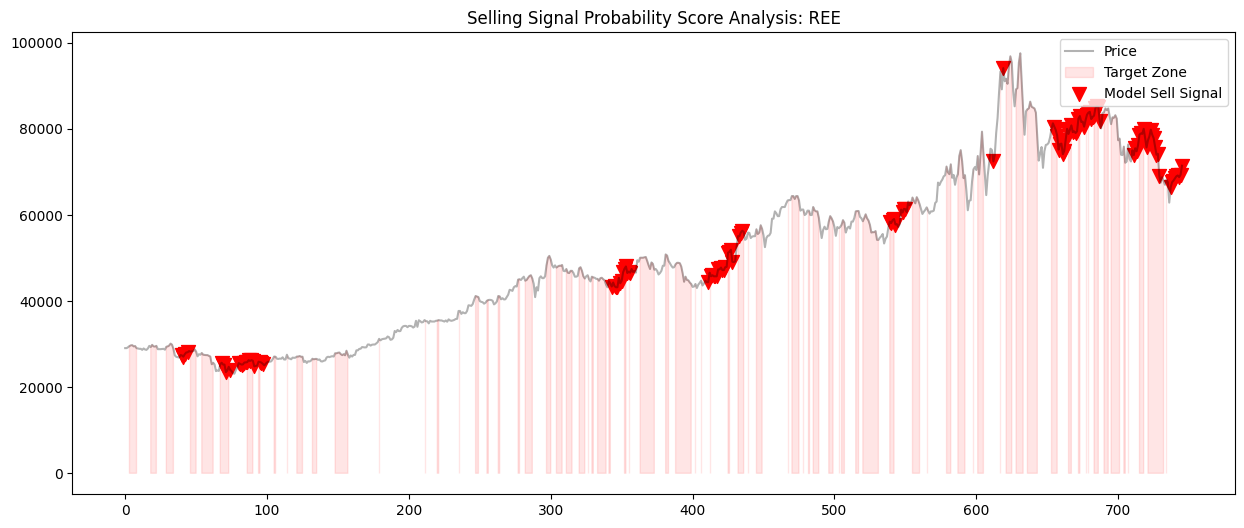

In [11]:
# Task 3.2: Selling signal

import torch, copy, pandas as pd, numpy as np, torch.nn as nn, matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report

# 1. Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
K_DAYS, WINDOW_SIZE, BATCH_SIZE, PROFIT_THRESHOLD = 5, 60, 64, 0.015

df_sell = vn_df[vn_df['Volume'] > 0].copy()
top_tickers = df_sell['Ticker'].value_counts().nlargest(200).index
df_sell = df_sell[df_sell['Ticker'].isin(top_tickers)]
df_sell = df_sell.sort_values(['Ticker', 'Date']).reset_index(drop=True)

# 2. Target Generation
df_sell['Sell_Signal'] = ((df_sell.groupby('Ticker')['Low'].shift(-K_DAYS) / df_sell['Close']) - 1 < -PROFIT_THRESHOLD).astype(int)
df_sell = df_sell.replace([np.inf, -np.inf], np.nan)
df_sell = df_sell.dropna().reset_index(drop=True)

# 3. Scaling & Split
f_cols = [c for c in df_sell.columns if c not in ['Ticker', 'Date', 'Buy_Signal', 'Signal', 'Sell_Signal']]
scaled_f = np.zeros((len(df_sell), len(f_cols)), dtype=np.float32)
targets = df_sell['Sell_Signal'].values
train_idx, val_idx, test_idx = [], [], []

for ticker, g in df_sell.groupby('Ticker'):
    idx = g.index.values
    if len(idx) < WINDOW_SIZE + 10: continue
    tr_end, val_end = int(len(idx)*0.7), int(len(idx)*0.85)
    scaler_sell = RobustScaler().fit(df_sell.loc[idx[:tr_end], f_cols])
    scaled_f[idx] = scaler_sell.transform(df_sell.loc[idx, f_cols])
    train_idx.extend([i for i in idx[:tr_end] if i + WINDOW_SIZE - 1 < idx[tr_end-1]])
    val_idx.extend([i for i in idx[tr_end:val_end] if i + WINDOW_SIZE - 1 < idx[val_end-1]])
    test_idx.extend([i for i in idx[val_end:] if i + WINDOW_SIZE - 1 < idx[-1]])

# Undersampling
train_sell_idx = [i for i in train_idx if targets[i + WINDOW_SIZE - 1] == 1]
train_no_sell_idx = [i for i in train_idx if targets[i + WINDOW_SIZE - 1] == 0]

n_no_sell_target = int(len(train_sell_idx) * 1.0)
n_no_sell = min(len(train_no_sell_idx), n_no_sell_target)
keep_no_sell_idx = np.random.choice(train_no_sell_idx, n_no_sell, replace=False).tolist()

undersampled_train_idx = train_sell_idx + keep_no_sell_idx
np.random.shuffle(undersampled_train_idx)
print(f"After Undersampling - Sell: {len(train_sell_idx)}, No Sell: {len(keep_no_sell_idx)}")

# 4. Model Architecture
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        weights = torch.softmax(self.attn(x), dim=1)
        return torch.sum(weights * x, dim=1)

class SOTA_Model(nn.Module):
    def __init__(self, in_sz):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_sz, 64, 3, padding=1), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, 128, 3, padding=1), nn.BatchNorm1d(128), nn.ReLU(),
            nn.MaxPool1d(2)
        )
        self.rnn = nn.GRU(128, 64, batch_first=True, bidirectional=True)
        self.attention = Attention(128)
        self.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(128, 1))
    def forward(self, x):
        x = self.cnn(x.permute(0, 2, 1))
        x, _ = self.rnn(x.permute(0, 2, 1))
        x = self.attention(x)
        return self.fc(x)

class SellDataset(Dataset):
    def __init__(self, f, t, idx): self.f, self.t, self.idx = torch.from_numpy(f), torch.from_numpy(t), idx
    def __len__(self): return len(self.idx)
    def __getitem__(self, i):
        s = self.idx[i]
        return self.f[s:s+WINDOW_SIZE], self.t[s+WINDOW_SIZE-1].float().unsqueeze(0)

# 5. Training
model_sell = SOTA_Model(len(f_cols)).to(device)
crit = nn.BCEWithLogitsLoss()
opt = torch.optim.AdamW(model_sell.parameters(), lr=1e-4)
loader = DataLoader(SellDataset(scaled_f, targets, undersampled_train_idx), batch_size=BATCH_SIZE, shuffle=True)

for epoch in range(15):
    model_sell.train()
    for X, y in loader:
        opt.zero_grad(); crit(model_sell(X.to(device)), y.to(device)).backward(); opt.step()

# 6. Evaluation
model_sell.eval()
all_probs, all_targets = [], []

test_loader = DataLoader(SellDataset(scaled_f, targets, test_idx), batch_size=BATCH_SIZE)
with torch.no_grad():
    for X, y in test_loader:
        prob = torch.sigmoid(model_sell(X.to(device))).cpu().numpy()
        all_probs.extend(prob.flatten())
        all_targets.extend(y.numpy().flatten())

# Accuracy Report
all_preds = (np.array(all_probs) > 0.5).astype(int)
print(classification_report(all_targets, all_preds, target_names=['No Sell', 'Sell']))

# Scoring Output
scoring_df = pd.DataFrame({'Probability_Score': all_probs, 'Actual': all_targets})
print("--- Sample Probability Scores (Selling) ---")
print(scoring_df.sort_values(by='Probability_Score', ascending=False).head(10))

# 7. Visualization
ticker = top_tickers[0]
sub = df_sell[(df_sell['Ticker'] == ticker) & (df_sell.index.isin(test_idx))].copy()
px, pred_sell, true_sell = [], [], []

for i in sub.index:
    X_in = torch.from_numpy(scaled_f[i-WINDOW_SIZE:i]).unsqueeze(0).to(device)
    with torch.no_grad():
        score = torch.sigmoid(model_sell(X_in)).item()

    px.append(df_sell.loc[i, 'Close'])
    pred_sell.append(df_sell.loc[i, 'Close'] if score > 0.6 else np.nan)
    true_sell.append(df_sell.loc[i, 'Close'] if df_sell.loc[i, 'Sell_Signal'] == 1 else np.nan)

plt.figure(figsize=(15, 6))
plt.plot(px, color='black', alpha=0.3, label='Price')
plt.fill_between(range(len(px)), px, where=~np.isnan(true_sell), color='red', alpha=0.1, label='Target Zone')
plt.scatter(range(len(px)), pred_sell, marker='v', color='red', s=100, label='Model Sell Signal')
plt.title(f"Selling Signal Probability Score Analysis: {ticker}")
plt.legend()
plt.show()

In [12]:
import joblib

# Save weight
torch.save(model_sell.state_dict(), 'vn_sell.pth')

# Save target_scalers
joblib.dump(scaler_sell, 'target_scalers_sell_vn.joblib')

# Save f_cols
joblib.dump(f_cols, 'f_cols_sell_vn.joblib')

# Save convig
config = {
    'WINDOW_SIZE': WINDOW_SIZE,
    'K_DAYS': K_DAYS,
    'PROFIT_THRESHOLD': PROFIT_THRESHOLD,
    'in_sz': len(f_cols),
}
joblib.dump(config, 'config_sell_vn.joblib')

['config_sell_vn.joblib']

In [13]:
# Task 4.1
def get_k_day_profitable_portfolio(df_source, model_buy, model_k_days, scaled_data, window_size, target_scalers_dict, k_days):
    model_buy.eval()
    model_k_days.eval()

    results = []
    unique_tickers = df_source['Ticker'].unique()

    for ticker in unique_tickers:
        try:
            ticker_data = df_source[df_source['Ticker'] == ticker]
            if len(ticker_data) < window_size or ticker not in target_scalers_dict:
                continue

            # Get latest window
            ticker_idx = ticker_data.index.values
            input_window = scaled_data[ticker_idx[-window_size:]]
            X_input = torch.tensor(input_window, dtype=torch.float32).unsqueeze(0).to(device)

            current_p = ticker_data['Close'].iloc[-1]
            t_scaler = target_scalers_dict[ticker]

            with torch.no_grad():
                # Inference
                buy_score = torch.sigmoid(model_buy(X_input)).item()
                scaled_preds = model_k_days(X_input).cpu().numpy()

                # Inverse Transform K-day differences
                real_diffs = t_scaler.inverse_transform(scaled_preds)[0]
                predicted_prices = current_p + real_diffs

                # Metrics calculation
                max_pred_p = np.max(predicted_prices)
                best_day = np.argmax(predicted_prices) + 1
                return_pct = (max_pred_p - current_p) / current_p

                # Selection Criteria
                if buy_score > 0.5 and return_pct > 0:
                    results.append({
                        'Ticker': ticker,
                        'Confidence': round(buy_score, 4),
                        'Current_Price': current_p,
                        'Max_Target': round(max_pred_p, 2),
                        'Best_Day': f"T+{best_day}",
                        'Max_Return (%)': round(return_pct * 100, 2),
                        'T+K_Price': round(predicted_prices[-1], 2)
                    })
        except:
            continue

    if not results: return pd.DataFrame()
    return pd.DataFrame(results).sort_values(by='Confidence', ascending=False)

# Execution
# Uses model (CNN_BiGRU) and target_scalers from Task 2.3
profitable_report = get_k_day_profitable_portfolio(
    df, model_buy, model, scaled_f, WINDOW_SIZE, target_scalers, K_DAYS
)

print(f"--- TOP PROFITABLE STOCKS ({K_DAYS}-DAY TRAJECTORY) ---")
print(profitable_report.head(15))

--- TOP PROFITABLE STOCKS (5-DAY TRAJECTORY) ---
   Ticker  Confidence  Current_Price  Max_Target Best_Day  Max_Return (%)  \
44    VNR      0.7105        24100.0    24440.09      T+5            1.41   
7     DHG      0.6740        98900.0    99338.41      T+5            0.44   
18    NTL      0.6682        17700.0    17722.56      T+5            0.13   
21    PVS      0.6563        26400.0    26702.78      T+5            1.15   
9     DTC      0.6543         5200.0     7932.30      T+5           52.54   
45    VTB      0.6424        13100.0    13126.22      T+5            0.20   
13    HJS      0.6299        34900.0    34935.66      T+5            0.10   
37    STP      0.6287         6900.0     8734.42      T+5           26.59   
36    SSI      0.6237        20450.0    20967.73      T+2            2.53   
39    TS4      0.6159         1300.0     1329.89      T+5            2.30   
14    HLY      0.6101        14200.0    14265.19      T+5            0.46   
8     DMC      0.6042      

In [14]:
# Task 4.2
def get_k_day_risk_portfolio(df_source, model_sell, model_k_days, scaled_data, window_size, target_scalers_dict, k_days):
    model_sell.eval()
    model_k_days.eval()

    results = []
    unique_tickers = df_source['Ticker'].unique()

    for ticker in unique_tickers:
        try:
            ticker_data = df_source[df_source['Ticker'] == ticker]
            if len(ticker_data) < window_size or ticker not in target_scalers_dict:
                continue

            # Get latest window
            ticker_idx = ticker_data.index.values
            input_window = scaled_data[ticker_idx[-window_size:]]
            X_input = torch.tensor(input_window, dtype=torch.float32).unsqueeze(0).to(device)

            current_p = ticker_data['Close'].iloc[-1]
            t_scaler = target_scalers_dict[ticker]

            with torch.no_grad():
                # Inference
                risk_score = torch.sigmoid(model_sell(X_input)).item()
                scaled_preds = model_k_days(X_input).cpu().numpy()

                # Inverse Transform K-day differences
                real_diffs = t_scaler.inverse_transform(scaled_preds)[0]
                predicted_prices = current_p + real_diffs

                # Metrics calculation: Find the worst drop in the K-day window
                min_pred_p = np.min(predicted_prices)
                worst_day = np.argmax(predicted_prices <= min_pred_p) + 1
                drop_pct = (min_pred_p - current_p) / current_p

                # Selection Criteria: High risk score and any projected price drop
                if risk_score > 0.5 and drop_pct < 0:
                    results.append({
                        'Ticker': ticker,
                        'Risk_Score': round(risk_score, 4),
                        'Current_Price': current_p,
                        'Min_Expected': round(min_pred_p, 2),
                        'Worst_Day': f"T+{worst_day}",
                        'Max_Drop (%)': round(drop_pct * 100, 2),
                        'T+K_Price': round(predicted_prices[-1], 2)
                    })
        except:
            continue

    if not results: return pd.DataFrame()
    return pd.DataFrame(results).sort_values(by='Risk_Score', ascending=False)

# Execution
# Uses model (CNN_BiGRU) and target_scalers from Task 2.3
risk_report = get_k_day_risk_portfolio(
    df, model_sell, model, scaled_f, WINDOW_SIZE, target_scalers, K_DAYS
)

print(f"--- HIGH RISK STOCKS ({K_DAYS}-DAY TRAJECTORY) ---")
print(risk_report.head(15))

--- HIGH RISK STOCKS (5-DAY TRAJECTORY) ---
   Ticker  Risk_Score  Current_Price  Min_Expected Worst_Day  Max_Drop (%)  \
41    SDY      0.8837         3600.0       3583.90       T+1         -0.45   
45    ST8      0.8026        17200.0      17015.04       T+5         -1.08   
44    SMC      0.7699        10300.0      10128.42       T+5         -1.67   
52    TTF      0.7631         4540.0       4300.22       T+5         -5.28   
2     AGF      0.7280         2700.0       2030.27       T+5        -24.80   
20    HNM      0.7120         6700.0       5505.19       T+5        -17.83   
53    UIC      0.7017        37000.0      36875.08       T+5         -0.34   
59    VTS      0.6976        24500.0      24497.43       T+1         -0.01   
1     ACB      0.6921        25500.0      25022.70       T+5         -1.87   
43    SGT      0.6893        12600.0       7373.75       T+5        -41.48   
47    TJC      0.6755        15600.0      15372.73       T+5         -1.46   
17    HDC      0.663

In [15]:
# Task 4.3
def interactive_k_day_optimization(profitable_df, risk_df):
    if profitable_df.empty:
        print("No profitable stocks found.")
        return None

    combined = profitable_df.merge(
        risk_df[['Ticker', 'Risk_Score']],
        on='Ticker',
        how='left'
    ).fillna({'Risk_Score': 0.5})

    print("\n--- SELECT STRATEGY ---")
    print("1. Prudent (Safety & Low Risk)")
    print("2. Risk-taking (Maximum Return)")
    strategy = input("Choice (1 or 2): ")

    # Calculate strategy-specific scores
    if strategy == '1':
        combined['Final_Score'] = (
            combined['Confidence'] * (combined['Max_Return (%)'] ** 0.5)
        ) / (combined['Risk_Score'] ** 2 + 1e-6)
        mode = "PRUDENT"
    else:
        combined['Final_Score'] = (
            combined['Confidence'] * combined['Max_Return (%)']
        ) / (combined['Risk_Score'] + 0.1)
        mode = "RISK-TAKING"

    combined = combined.sort_values(by='Final_Score', ascending=False).reset_index(drop=True)

    try:
        n_stocks = int(input(f"\nNumber of stocks (1-{len(combined)}): "))
        n_stocks = max(1, min(n_stocks, len(combined)))
    except ValueError:
        n_stocks = 5

    # Allocation and Returns
    final_selection = combined.head(n_stocks).copy()
    total_score = final_selection['Final_Score'].sum()
    final_selection['Weight (%)'] = (final_selection['Final_Score'] / total_score) * 100

    # Portfolio Expected Return = Sum(Weight_i * Return_i)
    portfolio_return = (final_selection['Max_Return (%)'] * (final_selection['Weight (%)'] / 100)).sum()

    output_cols = [
        'Ticker', 'Confidence', 'Risk_Score',
        'Max_Return (%)', 'Best_Day', 'Max_Target', 'Weight (%)'
    ]

    return final_selection[output_cols], mode, portfolio_return

# Execution
result = interactive_k_day_optimization(profitable_report, risk_report)

if result:
    df, mode, p_return = result
    print(f"\n--- {mode} PORTFOLIO ---")
    print(df.to_string(index=False))
    print(f"\nExpected Portfolio Return: {p_return:.2f}%")
    print("Total Allocation: 100.00%")


--- SELECT STRATEGY ---
1. Prudent (Safety & Low Risk)
2. Risk-taking (Maximum Return)
Choice (1 or 2): 1

Number of stocks (1-48): 5

--- PRUDENT PORTFOLIO ---
Ticker  Confidence  Risk_Score  Max_Return (%) Best_Day  Max_Target  Weight (%)
   DTC      0.6543         0.5           52.54      T+5     7932.30   35.152622
   STP      0.6287         0.5           26.59      T+5     8734.42   24.029150
   HSI      0.5799         0.5           17.48      T+5     1292.26   17.970477
   CID      0.5866         0.5            7.48      T+5     7308.32   11.891281
   SGD      0.5798         0.5            6.50      T+5    25879.80   10.956470

Expected Portfolio Return: 29.60%
Total Allocation: 100.00%
